###  Import libraries 

In [1]:
import pandas as pd
import numpy as np;
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

####  Load data with added features 

In [2]:
df = pd.read_parquet("../data/processed/features.parquet")

### Preview the data

In [3]:
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,...,work_life_balance,late_night_user,stress_risk_index,productivity_loss_score,weekend_behavior_shift,distraction_index,stress_sleep_interaction,phone_usage_per_age,productivity_usage_ratio,social_media_addict
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,...,5.076923,0,3.85,1.451667,6.692308,8.71,-3.2,0.022414,4.615385,1
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,...,3.333333,0,3.20,0.360000,4.250000,1.80,1.6,0.048000,4.166667,0
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,...,1.061321,0,5.65,6.042000,1.188679,30.21,-4.0,0.278947,0.943396,1
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,...,0.245690,0,8.20,7.250000,2.206897,14.50,6.9,0.165714,0.344828,0
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,...,0.360759,1,9.25,2.567500,1.253165,10.27,6.9,0.239394,0.506329,0


### Check the number of rows and columns 

In [4]:
df.shape

(50000, 30)

### Model preparation

In [5]:
target = df["Work_Productivity_Score"]

#### Select feature ( the input variables)

We then remove the columns we don't need in this model

In [6]:
features = df.drop(columns=["User_ID", "Work_Productivity_Score"])

In [7]:
X = features
y = target

#### Convert Categorical Variables
We convert the dummy variable using one hot encoding

In [8]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,Age,Daily_Phone_Hours,Social_Media_Hours,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,social_media_ratio,weekend_usage_increase,...,stress_sleep_interaction,phone_usage_per_age,productivity_usage_ratio,social_media_addict,Gender_Male,Gender_Other,Occupation_Freelancer,Occupation_Professional,Occupation_Student,Device_Type_iOS
0,58,1.3,6.7,8.8,4,42,1,8.7,5.153846,7.4,...,-3.2,0.022414,4.615385,1,True,False,False,True,False,False
1,25,1.2,1.5,6.4,1,51,3,5.1,1.250000,3.9,...,1.6,0.048000,4.166667,0,True,False,False,True,False,False
2,19,5.3,5.7,9.0,4,14,5,6.3,1.075472,1.0,...,-4.0,0.278947,0.943396,1,True,False,False,False,True,True
3,35,5.8,2.5,5.7,3,36,6,12.8,0.431034,7.0,...,6.9,0.165714,0.344828,0,False,False,False,False,False,True
4,33,7.9,1.3,5.7,3,37,5,9.9,0.164557,2.0,...,6.9,0.239394,0.506329,0,True,False,True,False,False,False


In [9]:
### Convert boolean columns to integers
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

In [10]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

### Split Data into Training and Testing Sets

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Feature Scaling 

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Linear Regression Model

In [13]:
lr = LinearRegression()


### Fit Linear Model

In [14]:
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Prediction

In [15]:
y_pred = lr.predict(X_test_scaled)

### Evaluation

In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")   
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 2.05
Root Mean Squared Error: 1.43
R^2 Score: 0.75


#### Visualization


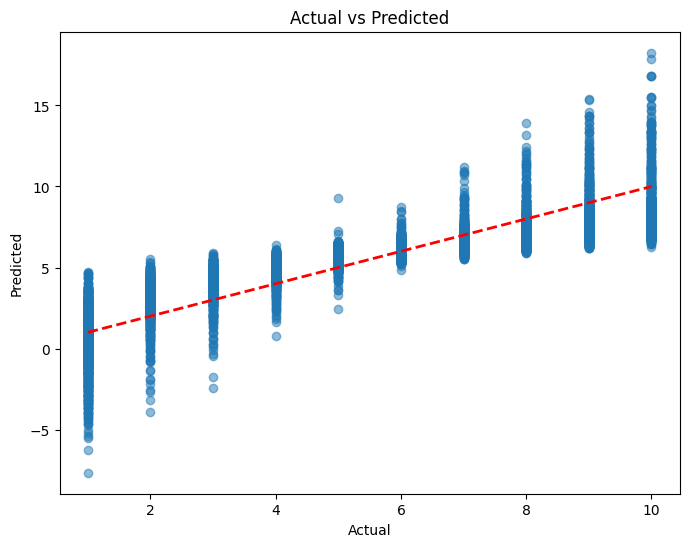

In [17]:
# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

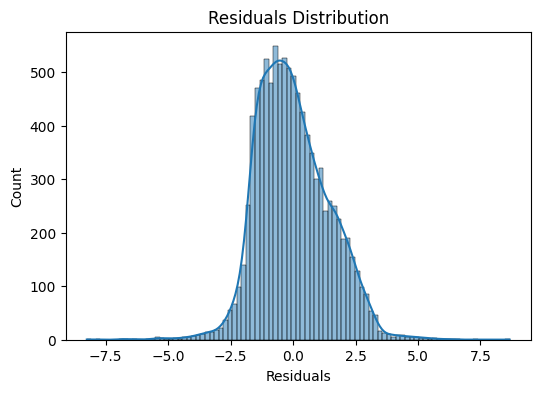

In [18]:
# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.show()

#### Correlation heatmap of features 

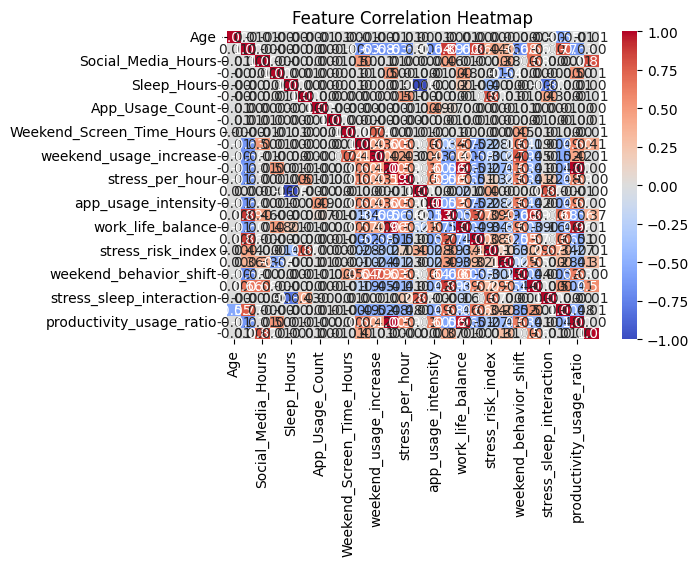

In [19]:
plt.figure(figsize=(6,4))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()